# Hybrid Search for Oracle AI Agent Memory: Combining Semantic Recall with Exact Match

This notebook demonstrates how Oracle AI Agent Memory retrieves durable memories using both semantic meaning and exact text. It uses one support-and-finance scenario throughout: **Northstar Renewals**, invoice **INV-48291**, Oracle error **ORA-27102**, and a renewal blocker caused by a reconciliation failure.

The notebook is designed for the Oracle AI Agent Memory 26.6 API. The hybrid-search section requires a database-resident embedding model that can be used by `OracleDBEmbedder`. The environment and database preflight cells can run before that model access is available; the notebook never substitutes mock retrieval results for Oracle hybrid search.

## What You Will Learn

- Configure Oracle AI Agent Memory with `SearchStrategy.HYBRID` and `OracleDBEmbedder`.
- Store memories that combine natural-language context with exact identifiers.
- Search the same scoped memories by invoice ID, error code, and semantic question.
- Understand how search scope and hybrid ranking solve different retrieval problems.
- Validate retrieval behavior without presenting a small demo as a formal benchmark.
- Apply the correct schema and index synchronization choices for production.

## Workflow

1. Validate the Python runtime and install Oracle AI Agent Memory 26.6.0 from PyPI.
2. Load database configuration without displaying secrets.
3. Connect to Oracle AI Database.
4. Discover database-resident embedding models.
5. Configure Oracle AI Agent Memory for Oracle-managed hybrid search.
6. Add scoped memories with exact identifiers and descriptive context.
7. Search by exact identifier and semantic meaning.
8. Validate top-ranked results and review production considerations.

## Prerequisites

- Python 3.10-3.13. Oracle AI Agent Memory 26.6.0 requires Python 3.10 or later and earlier than Python 3.14.
- Oracle AI Agent Memory 26.6.0 installed from PyPI by the setup cell below.
- Access to Oracle AI Database.
- A database-resident embedding model for the complete hybrid-search run.
- An `.env` file in the project folder:

```env
ORACLE_USER=
ORACLE_PASSWORD=
ORACLE_DSN=
ORACLE_DB_EMBEDDING_MODEL=
ORACLE_DB_EMBEDDING_DIMENSION=384
```

The first three settings establish the database connection. The model name and its correct dimension are required before creating `OracleDBEmbedder`. Keep the real `.env` file private and do not commit it to source control.

## Install and Validate the Environment

This single setup cell validates the active Python runtime, installs Oracle AI Agent Memory 26.6.0 and the notebook dependencies into the current kernel without displaying package indexes or local paths, and confirms the installed package version.


In [1]:
import sys
from importlib.metadata import version

from IPython.utils.capture import capture_output


assert (3, 10) <= sys.version_info[:2] <= (3, 13), (
    f"Python 3.10-3.13 is required; found {sys.version.split()[0]}"
)

with capture_output():
    get_ipython().run_line_magic(
        "pip",
        "install oracleagentmemory==26.6.0 oracledb pandas matplotlib python-dotenv --quiet",
    )

package_version = version("oracleagentmemory")
assert package_version == "26.6.0", (
    f"Oracle AI Agent Memory 26.6.0 is required; found {package_version}"
)

print("Python and Oracle AI Agent Memory environment: READY")

Python and Oracle AI Agent Memory environment: READY


## Step 1 - Load Configuration and Connect to Oracle AI Database

This step loads the private `.env` file, validates the required settings, and opens one thin-mode `python-oracledb` connection. It reports only readiness and never displays usernames, passwords, DSNs, database versions, schema names, or model details.


In [2]:
import os
from pathlib import Path

import oracledb
import pandas as pd
from dotenv import load_dotenv


def find_project_dir(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".env").exists():
            return candidate
    raise FileNotFoundError(
        "No .env file was found. Create it in the notebook folder before continuing."
    )


PROJECT_DIR = find_project_dir(Path.cwd())
load_dotenv(PROJECT_DIR / ".env", override=False)

CONFIG = {
    "ORACLE_USER": os.getenv("ORACLE_USER", "").strip(),
    "ORACLE_PASSWORD": os.getenv("ORACLE_PASSWORD", ""),
    "ORACLE_DSN": os.getenv("ORACLE_DSN", "").strip(),
    "ORACLE_DB_EMBEDDING_MODEL": os.getenv("ORACLE_DB_EMBEDDING_MODEL", "").strip(),
    "ORACLE_DB_EMBEDDING_DIMENSION": int(
        os.getenv("ORACLE_DB_EMBEDDING_DIMENSION", "384")
    ),
}

required_connection_keys = ["ORACLE_USER", "ORACLE_PASSWORD", "ORACLE_DSN"]
missing = [key for key in required_connection_keys if not CONFIG[key]]
if missing:
    raise RuntimeError(f"Missing required database settings: {', '.join(missing)}")

try:
    connection = oracledb.connect(
        user=CONFIG["ORACLE_USER"],
        password=CONFIG["ORACLE_PASSWORD"],
        dsn=CONFIG["ORACLE_DSN"],
    )
except oracledb.Error as exc:
    error = exc.args[0]
    raise RuntimeError(
        "Oracle Database is not reachable with the configured connection. "
        f"Oracle driver error code: {getattr(error, 'code', 'unknown')}"
    ) from exc

DB_READY = True
DB_BLOCKER = ""
print("Configuration and database connection: READY")

Configuration and database connection: READY


## Step 2 - Validate the Database Embedding Model

Oracle-managed hybrid search requires `OracleDBEmbedder`, which in turn requires a database-resident embedding model. This read-only preflight checks whether the model configured in `.env` is available to the connected application.

The validation deliberately reports only readiness. Model names, catalog views, algorithms, database versions, and schema names are environment-specific implementation details and are not displayed in this public notebook.

In [3]:
def discover_embedding_models(db_connection):
    queries = [
        (
            "USER_MINING_MODELS",
            """SELECT model_name, mining_function, algorithm
                 FROM user_mining_models
                WHERE UPPER(mining_function) = 'EMBEDDING'
                ORDER BY model_name""",
        ),
        (
            "ALL_MINING_MODELS",
            """SELECT owner || '.' || model_name AS model_name, mining_function, algorithm
                 FROM all_mining_models
                WHERE UPPER(mining_function) = 'EMBEDDING'
                ORDER BY owner, model_name""",
        ),
    ]

    errors = []
    for source, query in queries:
        try:
            with db_connection.cursor() as cursor:
                rows = cursor.execute(query).fetchall()
            return source, pd.DataFrame(rows, columns=["model_name", "mining_function", "algorithm"]), errors
        except oracledb.DatabaseError as exc:
            error = exc.args[0]
            errors.append(f"{source}: {getattr(error, 'code', 'unknown error')}")

    return "UNAVAILABLE", pd.DataFrame(columns=["model_name", "mining_function", "algorithm"]), errors


if DB_READY:
    model_source, embedding_models, discovery_errors = discover_embedding_models(connection)
else:
    model_source = "NOT_CONNECTED"
    embedding_models = pd.DataFrame(columns=["model_name", "mining_function", "algorithm"])
    discovery_errors = []

configured_model = CONFIG["ORACLE_DB_EMBEDDING_MODEL"]
visible_models = set(embedding_models["model_name"].astype(str))

if not DB_READY:
    HYBRID_READY = False
    HYBRID_STATUS = DB_BLOCKER
elif configured_model and model_source == "UNAVAILABLE":
    HYBRID_READY = True
    HYBRID_STATUS = "Model catalog is unavailable; the configured model will be validated by OracleDBEmbedder."
elif configured_model and configured_model in visible_models:
    HYBRID_READY = True
    HYBRID_STATUS = "The configured database embedding model is available."
elif configured_model:
    HYBRID_READY = False
    HYBRID_STATUS = "Configured model was not found among models visible to this schema."
else:
    HYBRID_READY = False
    HYBRID_STATUS = "ORACLE_DB_EMBEDDING_MODEL is not configured."

if not DB_READY:
    HYBRID_BLOCKER = DB_BLOCKER
else:
    HYBRID_BLOCKER = (
        "A database-resident embedding model is required. Ask the package team for the "
        "Oracle Database/schema connection, model name, and embedding dimension to use with OracleDBEmbedder."
    )

if HYBRID_READY:
    print("Database embedding model: READY")
    print("Hybrid search prerequisites: READY")
else:
    print("Database embedding model: BLOCKED")
    print("Hybrid search prerequisites: BLOCKED")
    print(HYBRID_STATUS)
    print(HYBRID_BLOCKER)

Database embedding model: READY
Hybrid search prerequisites: READY


### Why the Database Model Matters

`OracleDBEmbedder` keeps embedding generation inside Oracle AI Database. The same database-resident model must be used for query embeddings and for the managed hybrid vector index so their vectors have compatible dimensions and semantics.

- Connection credentials and model configuration are read from `.env` and are never printed.
- The model name and embedding dimension are deployment-specific.
- Model discovery is a prerequisite check, not part of the retrieval demonstration.
- A successful preflight confirms that the notebook can proceed with `OracleDBEmbedder` and managed hybrid indexing.

If validation is blocked, confirm that the configured database user can access the intended embedding model and create or query the managed hybrid vector index.

## Step 3 - Configure Oracle AI Agent Memory for Hybrid Search

`SearchStrategy.HYBRID` combines Oracle-managed text matching with vector-aware ranking. `OracleDBEmbedder` ensures the memory client and the managed hybrid vector index use the same in-database model. `ON_COMMIT` makes newly committed memories searchable immediately, which is appropriate for this interactive walkthrough.

In [4]:
from oracleagentmemory.apis.searchscope import SearchScope
from oracleagentmemory.core import (
    MemoryExtractionConfig,
    OracleAgentMemory,
    SchemaPolicy,
    SearchIndexSyncMode,
    SearchStrategy,
)
from oracleagentmemory.core.embedders import OracleDBEmbedder


def require_hybrid_ready() -> None:
    if not HYBRID_READY:
        raise RuntimeError(HYBRID_BLOCKER)


print("Oracle AI Agent Memory 26.6 hybrid-search imports: READY")

Oracle AI Agent Memory 26.6 hybrid-search imports: READY


In [5]:
require_hybrid_ready()

db_embedder = OracleDBEmbedder(
    connection=connection,
    model=CONFIG["ORACLE_DB_EMBEDDING_MODEL"],
    embedding_dimension=CONFIG["ORACLE_DB_EMBEDDING_DIMENSION"],
)

memory = OracleAgentMemory(
    connection=connection,
    embedder=db_embedder,
    memory_extraction_config=MemoryExtractionConfig(extract_memories=False),
    schema_policy=SchemaPolicy.CREATE_IF_NECESSARY,
    search_strategy=SearchStrategy.HYBRID,
    search_index_sync=SearchIndexSyncMode.ON_COMMIT,
    memory_store_id="hybrid_blog",
)

print("Oracle-managed hybrid search client: READY")

Oracle-managed hybrid search client: READY


`SchemaPolicy.CREATE_IF_NECESSARY` is intentional for the first setup. It may create or upgrade managed search objects and build the hybrid index. For a large existing schema, run this as a planned migration. After the schema is ready, production applications can use `SchemaPolicy.REQUIRE_EXISTING` for normal startup validation.

## Step 4 - Register a Scoped User and Agent

Scope determines which records are eligible for retrieval. Hybrid search then ranks only those eligible records. A unique run identifier keeps repeated notebook runs isolated while preserving one stable managed memory store.

In [6]:
import uuid

require_hybrid_ready()

RUN_ID = uuid.uuid4().hex[:8]
USER_ID = f"finance_user_{RUN_ID}"
AGENT_ID = f"support_finance_{RUN_ID}"

memory.add_user(
    user_id=USER_ID,
    information="Finance user with access to renewal-related data.",
)
memory.add_agent(
    agent_id=AGENT_ID,
    information="Support-finance agent for invoices, reconciliation failures, and renewal blockers.",
)

scope = SearchScope(user_id=USER_ID, agent_id=AGENT_ID)
print("Scoped demo user and agent: READY")

Scoped demo user and agent: READY


## Step 5 - Build a Deliberately Ambiguous Memory Set

The dataset combines exact operational handles with natural-language context. It also includes carefully chosen distractors: a neighboring invoice, a different customer's renewal delay, a general error-code explanation, and a customer-alias record.

This matters because a useful retrieval demo should not succeed merely because there is only one record. The target memory must outrank records that overlap on customer, invoice, renewal, or error vocabulary.

In [7]:
require_hybrid_ready()

sample_memories = [
    {
        "label": "renewal_blocker",
        "content": (
            "Northstar Renewals cannot proceed with its renewal because invoice INV-48291 "
            "failed reconciliation after ORA-27102 during month-end processing. Finance must "
            "rerun the reconciliation job before the renewal can continue."
        ),
        "metadata": {
            "customer_alias": "Northstar Renewals",
            "invoice_id": "INV-48291",
            "error_code": "ORA-27102",
        },
    },
    {
        "label": "similar_invoice",
        "content": (
            "Northstar Renewals also has invoice INV-48290 marked as paid. "
            "No finance follow-up is required for that invoice."
        ),
        "metadata": {"customer_alias": "Northstar Renewals", "invoice_id": "INV-48290"},
    },
    {
        "label": "milan_renewal",
        "content": (
            "Milan Office Supplies experienced a renewal delay because its approval workflow "
            "was waiting for a regional manager. No reconciliation error was reported."
        ),
        "metadata": {"customer_alias": "Milan Office Supplies"},
    },
    {
        "label": "error_reference",
        "content": (
            "ORA-27102 can indicate memory allocation pressure. Database memory settings "
            "should be checked before rerunning affected batch processing."
        ),
        "metadata": {"error_code": "ORA-27102"},
    },
    {
        "label": "customer_alias",
        "content": (
            "Northstar Renewals maps to the enterprise account Northstar Renewal Services Ltd. "
            "Finance operations owns escalations for that account."
        ),
        "metadata": {"customer_alias": "Northstar Renewals"},
    },
]

for item in sample_memories:
    memory.add_memory(
        item["content"],
        user_id=USER_ID,
        agent_id=AGENT_ID,
        metadata={**item["metadata"], "label": item["label"], "demo": "hybrid-search"},
    )

memory_inventory = pd.DataFrame(
    [
        {
            "label": "renewal_blocker",
            "exact_signal": "INV-48291 · ORA-27102 · Northstar Renewals",
            "semantic_context": "Failed reconciliation blocked a renewal",
            "evaluation_role": "Primary target",
        },
        {
            "label": "similar_invoice",
            "exact_signal": "INV-48290 · Northstar Renewals",
            "semantic_context": "Neighboring invoice, already paid",
            "evaluation_role": "Exact-ID distractor",
        },
        {
            "label": "milan_renewal",
            "exact_signal": "Milan Office Supplies",
            "semantic_context": "Renewal delayed by approval workflow",
            "evaluation_role": "Semantic distractor",
        },
        {
            "label": "error_reference",
            "exact_signal": "ORA-27102",
            "semantic_context": "General error-code explanation",
            "evaluation_role": "Exact-code target",
        },
        {
            "label": "customer_alias",
            "exact_signal": "Northstar Renewals",
            "semantic_context": "Enterprise account mapping",
            "evaluation_role": "Alias distractor",
        },
    ]
)

display(
    memory_inventory.style
    .hide(axis="index")
    .set_caption("Memory inventory used by the retrieval evaluation")
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_table_styles(
        [
            {"selector": "caption", "props": "font-weight: 700; text-align: left; padding: 8px 0;"},
            {"selector": "th", "props": "background-color: #312d2a; color: white; text-align: left; padding: 8px;"},
            {"selector": "td", "props": "border-bottom: 1px solid #d9d4cf; padding: 8px;"},
        ]
    )
)

label,exact_signal,semantic_context,evaluation_role
renewal_blocker,INV-48291 · ORA-27102 · Northstar Renewals,Failed reconciliation blocked a renewal,Primary target
similar_invoice,INV-48290 · Northstar Renewals,"Neighboring invoice, already paid",Exact-ID distractor
milan_renewal,Milan Office Supplies,Renewal delayed by approval workflow,Semantic distractor
error_reference,ORA-27102,General error-code explanation,Exact-code target
customer_alias,Northstar Renewals,Enterprise account mapping,Alias distractor


## Step 6 - Define One Reusable Search Path

Every evaluation query uses the same documented `SearchScope` overload and the same Oracle-managed hybrid index. This keeps the comparison focused on the query rather than on changes in configuration.

`OracleSearchResult.distance` is used for display: smaller values indicate a stronger match. The result metadata carries the human-readable label used by the validation summary.

In [8]:
async def search_memory(query: str, max_results: int = 5) -> pd.DataFrame:
    require_hybrid_ready()
    results = await memory.search_async(
        query=query,
        scope=scope,
        max_results=max_results,
        record_types=["memory"],
    )
    return pd.DataFrame(
        [
            {
                "rank": rank,
                "distance": result.distance,
                "label": (result.metadata or {}).get("label", ""),
                "record_type": result.record.record_type,
                "content": result.content,
                "metadata": result.metadata or {},
            }
            for rank, result in enumerate(results, start=1)
        ]
    )


print("Hybrid search helper: READY")

Hybrid search helper: READY


## Step 7 - Run the Retrieval Evaluation

### What to observe

The five cases exercise three retrieval patterns:

- **Exact identifier:** the query is only an invoice ID or error code.
- **Semantic:** the query describes the event without repeating its stored wording.
- **Mixed:** the query combines business meaning with a named customer or object.

A case passes only when the expected memory is ranked first. The evaluation is intentionally small and deterministic; it validates the tutorial workflow, not general retrieval quality.

In [9]:
evaluation_cases = [
    {
        "case_id": "exact_invoice",
        "category": "Exact identifier",
        "query": "INV-48291",
        "expected_label": "renewal_blocker",
        "expected_text": "INV-48291",
    },
    {
        "case_id": "exact_error",
        "category": "Exact identifier",
        "query": "ORA-27102",
        "expected_label": "error_reference",
        "expected_text": "ORA-27102",
    },
    {
        "case_id": "semantic_blocker",
        "category": "Semantic",
        "query": "What blocked the Northstar renewal?",
        "expected_label": "renewal_blocker",
        "expected_text": "INV-48291",
    },
    {
        "case_id": "semantic_milan",
        "category": "Semantic",
        "query": "Which issue delayed the Milan customer renewal?",
        "expected_label": "milan_renewal",
        "expected_text": "Milan Office Supplies",
    },
    {
        "case_id": "mixed_invoice_context",
        "category": "Mixed",
        "query": "Which invoice failed reconciliation for Northstar?",
        "expected_label": "renewal_blocker",
        "expected_text": "INV-48291",
    },
]

evaluation_results = {}
summary_rows = []

for case in evaluation_cases:
    ranked = await search_memory(case["query"])
    evaluation_results[case["case_id"]] = ranked
    assert not ranked.empty, f"No results returned for {case['query']!r}"

    top = ranked.iloc[0]
    passed = (
        top["label"] == case["expected_label"]
        and case["expected_text"] in str(top["content"])
    )
    assert passed, (
        f"Unexpected top result for {case['query']!r}: "
        f"expected {case['expected_label']!r}, received {top['label']!r}"
    )

    summary_rows.append(
        {
            "category": case["category"],
            "query": case["query"],
            "expected": case["expected_label"],
            "top_result": top["label"],
            "distance": float(top["distance"]),
            "status": "PASS",
        }
    )

evaluation_summary = pd.DataFrame(summary_rows)

def highlight_status(value):
    return "background-color: #e7f4e4; color: #1b5e20; font-weight: 700" if value == "PASS" else ""

display(
    evaluation_summary.style
    .hide(axis="index")
    .format({"distance": "{:.4f}"})
    .map(highlight_status, subset=["status"])
    .set_caption("Hybrid retrieval evaluation summary")
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_table_styles(
        [
            {"selector": "caption", "props": "font-weight: 700; text-align: left; padding: 8px 0;"},
            {"selector": "th", "props": "background-color: #312d2a; color: white; text-align: left; padding: 8px;"},
            {"selector": "td", "props": "border-bottom: 1px solid #d9d4cf; padding: 8px;"},
        ]
    )
)

category,query,expected,top_result,distance,status
Exact identifier,INV-48291,renewal_blocker,renewal_blocker,0.4191,PASS
Exact identifier,ORA-27102,error_reference,error_reference,0.3757,PASS
Semantic,What blocked the Northstar renewal?,renewal_blocker,renewal_blocker,0.2534,PASS
Semantic,Which issue delayed the Milan customer renewal?,milan_renewal,milan_renewal,0.2914,PASS
Mixed,Which invoice failed reconciliation for Northstar?,renewal_blocker,renewal_blocker,0.2152,PASS


## Step 8 - Compare Top-Result Strength

The chart below makes the five successful cases easier to compare at a glance. Distance is shown only to explain this run: **smaller distance indicates a stronger match**. Different query shapes naturally produce different values, so this is not a cross-system benchmark.

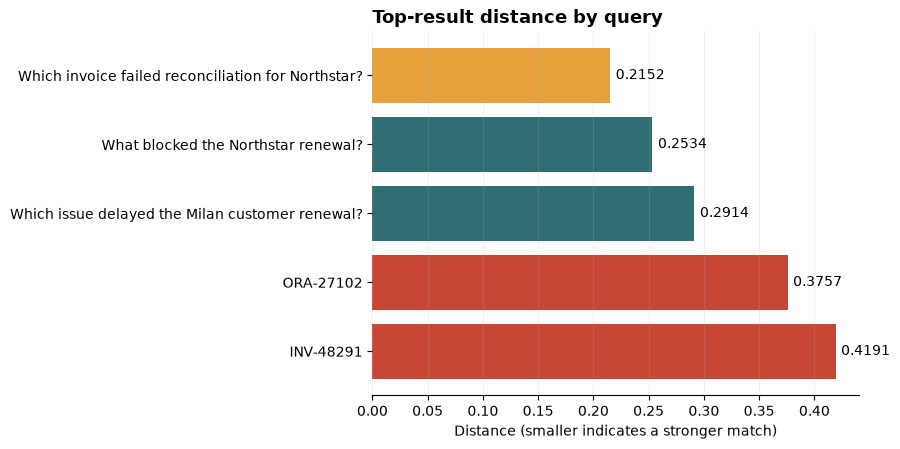

In [10]:
import matplotlib.pyplot as plt

plot_data = evaluation_summary.sort_values("distance", ascending=True)
colors = plot_data["category"].map(
    {"Exact identifier": "#c74634", "Semantic": "#2f6f73", "Mixed": "#e6a23c"}
)

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(plot_data["query"], plot_data["distance"], color=colors)
ax.invert_yaxis()
ax.set_title("Top-result distance by query", loc="left", fontsize=13, fontweight="bold")
ax.set_xlabel("Distance (smaller indicates a stronger match)")
ax.grid(axis="x", alpha=0.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.bar_label(bars, labels=[f"{value:.4f}" for value in plot_data["distance"]], padding=4)
plt.tight_layout()
plt.show()

### Reading the results

Every query returned its expected memory at rank 1. Exact queries preserved literal identifiers, while semantic queries recovered the correct event from business-language descriptions. The mixed query is the most representative enterprise case because it combines intent, customer context, and an implied operational object.

To keep the notebook concise, only that mixed case is expanded below.

In [11]:
detailed_results = evaluation_results["mixed_invoice_context"][
    ["rank", "distance", "label", "content"]
].copy()

display(
    detailed_results.style
    .hide(axis="index")
    .format({"distance": "{:.4f}"})
    .set_caption("Detailed ranking for: Which invoice failed reconciliation for Northstar?")
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_table_styles(
        [
            {"selector": "caption", "props": "font-weight: 700; text-align: left; padding: 8px 0;"},
            {"selector": "th", "props": "background-color: #312d2a; color: white; text-align: left; padding: 8px;"},
            {"selector": "td", "props": "border-bottom: 1px solid #d9d4cf; padding: 8px;"},
            {"selector": "tbody tr:first-child", "props": "background-color: #e7f4e4;"},
        ]
    )
)

rank,distance,label,content
1,0.2152,renewal_blocker,Northstar Renewals cannot proceed with its renewal because invoice INV-48291 failed reconciliation after ORA-27102 during month-end processing. Finance must rerun the reconciliation job before the renewal can continue.
2,0.2974,similar_invoice,Northstar Renewals also has invoice INV-48290 marked as paid. No finance follow-up is required for that invoice.
3,0.4134,customer_alias,Northstar Renewals maps to the enterprise account Northstar Renewal Services Ltd. Finance operations owns escalations for that account.
4,0.4265,milan_renewal,Milan Office Supplies experienced a renewal delay because its approval workflow was waiting for a regional manager. No reconciliation error was reported.
5,0.5170,error_reference,ORA-27102 can indicate memory allocation pressure. Database memory settings should be checked before rerunning affected batch processing.


## Vector, Keyword, and Hybrid Search

The comparison below is conceptual. This notebook executes the hybrid configuration only; it does not claim to benchmark three independently configured search stores.

In [12]:
search_mode_comparison = pd.DataFrame(
    [
        {
            "mode": "Vector",
            "best_at": "Meaning, paraphrase, and conceptual similarity",
            "weak_spot": "Short identifiers can be underweighted",
            "example": "What blocked the renewal?",
        },
        {
            "mode": "Keyword",
            "best_at": "Exact IDs, error codes, aliases, and filenames",
            "weak_spot": "Different wording can miss the stored record",
            "example": "INV-48291",
        },
        {
            "mode": "Hybrid",
            "best_at": "Natural-language intent plus exact operational handles",
            "weak_spot": "Requires database embedding and managed index setup",
            "example": "Why did INV-48291 block the renewal?",
        },
    ]
)
display(
    search_mode_comparison.style
    .hide(axis="index")
    .set_caption("Conceptual retrieval-mode comparison")
    .set_properties(**{"text-align": "left", "white-space": "normal"})
    .set_table_styles(
        [
            {"selector": "caption", "props": "font-weight: 700; text-align: left; padding: 8px 0;"},
            {"selector": "th", "props": "background-color: #312d2a; color: white; text-align: left; padding: 8px;"},
            {"selector": "td", "props": "border-bottom: 1px solid #d9d4cf; padding: 8px;"},
        ]
    )
)

mode,best_at,weak_spot,example
Vector,"Meaning, paraphrase, and conceptual similarity",Short identifiers can be underweighted,What blocked the renewal?
Keyword,"Exact IDs, error codes, aliases, and filenames",Different wording can miss the stored record,INV-48291
Hybrid,Natural-language intent plus exact operational handles,Requires database embedding and managed index setup,Why did INV-48291 block the renewal?


## Scoped Retrieval

Scope and hybrid ranking are complementary:

- `SearchScope` determines which memories are eligible.
- Hybrid retrieval ranks those eligible memories using semantic and exact-text signals.

Every evaluation query above used one generated finance-user and support-agent scope. The scope selected eligible records before the hybrid index ranked them.

In [13]:
scope_confirmation = pd.DataFrame(
    [
        {
            "scope": "Generated finance user + support-finance agent",
            "evaluated_queries": len(evaluation_cases),
            "eligible_demo_memories": len(sample_memories),
            "top_result_validations": f"{(evaluation_summary['status'] == 'PASS').sum()}/{len(evaluation_summary)} PASS",
        }
    ]
)
display(scope_confirmation.style.hide(axis="index"))

scope,evaluated_queries,eligible_demo_memories,top_result_validations
Generated finance user + support-finance agent,5,5,5/5 PASS


## What this demonstration proves

- Oracle AI Agent Memory 26.6 can configure Oracle-managed hybrid search with `OracleDBEmbedder`.
- One scoped memory store can retrieve exact identifiers and semantically described events through the same search API.
- In this controlled dataset, all five expected memories were ranked first despite overlapping distractors.
- Saved outputs are generated by the real database-resident embedding model and hybrid index, not by a local mock.

## What this demonstration does not prove

- It is not a benchmark of general retrieval accuracy or latency.
- It does not isolate the individual contribution of vector and keyword signals.
- It does not compare separate vector-only, keyword-only, and hybrid stores.

Those questions require a larger labeled dataset, repeated runs, fixed evaluation metrics, and separately configured retrieval strategies.

## Practical Production Notes

- **Initial schema setup:** use `SchemaPolicy.CREATE_IF_NECESSARY` intentionally when enabling hybrid search or upgrading a managed schema.
- **First hybrid index build:** Oracle scans existing search text and builds managed text/vector state. Treat this as a migration or maintenance operation for a large schema.
- **Normal startup:** after setup, consider `SchemaPolicy.REQUIRE_EXISTING` so the application validates rather than modifies schema objects.
- **`ON_COMMIT`:** newly committed memories become searchable immediately; useful for notebooks and interactive applications.
- **`MANUAL`:** appropriate for bulk loads and controlled refresh workflows.
- **`AUTO`:** Oracle-managed background refresh for hybrid search when some freshness lag is acceptable. `AUTO` is not supported for keyword-only search.
- **Strategy transitions:** do not reopen a keyword/hybrid schema as vector-only without following the documented recreation or embedding-backfill guidance.
- **Advanced exact-text indexing:** store-level `index_texts`/`index_text` can index identifiers, aliases, and short phrases while keeping visible record content concise.

## Resources

- [Oracle AI Agent Memory 26.6.0 on PyPI](https://pypi.org/project/oracleagentmemory/26.6.0/)
- [Oracle AI Agent Memory documentation](https://docs.oracle.com/en/database/oracle/agent-memory/26.4/)
- [Oracle AI Vector Search User's Guide](https://docs.oracle.com/en/database/oracle/oracle-database/26/vecse/)

## Optional Cleanup

The demo uses unique user and agent identifiers so repeated runs do not collide. Run the following cell when you no longer need to inspect this run's records. It removes the generated demo scope and closes the client and database connection. Leave it unexecuted if you want to inspect the stored records after the walkthrough.

In [14]:
deleted_user_records = memory.delete_user(USER_ID, cascade=True)
deleted_agent_records = memory.delete_agent(AGENT_ID, cascade=True)
memory.close()
connection.close()

print("Demo data removed and database connection closed.")

Demo data removed and database connection closed.


## Summary

This notebook demonstrates Oracle-managed hybrid search with the Oracle AI Agent Memory 26.6 API and a database-resident embedding model. It stores durable scoped memories, searches by exact identifiers and semantic questions, and validates the expected top results against deliberately similar records.

The consolidated evaluation keeps the output readable while preserving the evidence needed for review: five real queries, five rank-1 validations, one distance overview, and one representative ranking. The conceptual retrieval-mode table provides context without claiming an unexecuted vector-versus-keyword benchmark.